In [1]:
import pandas as pd
import numpy as np
import scipy.stats as st
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os

mpl.rcParams.update({
    # --- Fonts: keep text editable ---
    'pdf.fonttype': 'truetype',   # same as 42, ensures TrueType fonts
    'ps.fonttype': 'truetype',    # for EPS compatibility
    'svg.fonttype': 'none',       # keeps SVG text as text, not outlines

    # --- PDF structure: keep elements separate ---
    'pdf.compression': 0,         # prevents grouping/merging of vector paths
    'savefig.transparent': True,  # optional: preserves transparent backgrounds
    'savefig.bbox': 'tight',      # trims whitespace
    'savefig.pad_inches': 0.02,   # small padding for Illustrator bleed safety

    # --- General style niceties ---
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.family': 'sans-serif'
})

from IPython.display import display, HTML
display(HTML("<style>.jp-Cell { margin-left: -20% !important; margin-right: -15% !important; }</style>"))

In [2]:
#Bar colours
treat_col = {0:'white',
            1: 'silver',
            2: '#808080'}

treat_col2 = {'Vehicle':'white',
            '1uM_AZA': 'silver',
            '3uM_AZA': '#808080'}

In [3]:
width = 0.6
sz=6

In [4]:
#----P18 plots----
#----Import data from Xioaheng
#Get sheet names
xls = pd.ExcelFile('../Data/P18_count_table_analysis.xls')
sheets18 = xls.sheet_names
sheets18.append('CB') #Add an extra dummy entry for spacing
sheets18

['CB', 'C1D1_HSC_suba', 'PD_subb', 'PD_subc', 'CB']

In [5]:
#----Manually add initial cell ceeding number from original excel formulas
seed_no18 = {'CB':9222,
           'C1D1_HSC_suba':4831,
           'PD_subb':3255,
           'PD_subc':9000}

#----Manually add colours for dots
source_col18 = {'CB':'#cbcacc',
           'C1_13':'#e2b8c4',
           'PD_15':'#c4738a',
           'PD_9':'#9f1c3e'}

#Manually add treatment dictionary (extract treatment codes from full df)
treat18 = {'R':'Rapa', 
         'V':'Vehicle', 
         '1AR':'1uM_AZA_Rapa', 
         '1A':'1uM_AZA', 
         '3AR':'3uM_AZA_Rapa', 
         '3A':'3uM_AZA'}

treat_co18 = {'R':3, 
         'V':0, 
         '1AR':4, 
         '1A':1, 
         '3AR':5, 
         '3A':2}

#convert cluster names for human readability
source_CL18 = {'CB':'CB',
           'C1D1_HSC_suba':'C1_13',
           'PD_subb':'PD_15',
           'PD_subc':'PD_9'}

po18 =  {'CB':0,
           'C1_13':1,
           'PD_15':2,
           'PD_9':3}

In [6]:
#Read in the data and perform calculations as neccesary

df18 = None
for s in sheets18[:-1]: #Can't iterate through extra CB entry lr data will get imported twice
    sd = pd.read_excel('../Data/P18_count_table_analysis.xls', sheet_name = s,  engine='xlrd', usecols = 'A:F')
    sd['Source'] = s
    sd['leiden'] = sd['Source'].replace(source_CL18)
    sd['Cells_seeded'] = seed_no18[s]
    sd['Total_count'] = sd['mCD105- | Count']/sd['Beads-2 | Count']*10000
    sd['Total_normalized_to_seeding'] = sd['Total_count']/sd['Cells_seeded']
    sd['Treatment'] = sd['Unnamed: 0'].str.split('_').str[-3].replace(treat18)
    sd['x_coord'] = sd['Unnamed: 0'].str.split('_').str[-3].replace(treat_co18)

    #Find vehicle average
    veh_mean = sd.loc[sd['Unnamed: 0'].str.contains('_V_')]['Total_count'].mean()
    sd['Total_normalized_to_vehicle'] = sd['Total_count']/veh_mean*100

    sd = sd.loc[sd['Unnamed: 0'].str.contains('Specimen')]

    #Convert percentages
    sd['CD34pos'] = sd['CD34pos | Freq. of Parent'].str.split(' ').str[0].astype('float')
    sd['CD34neg'] = sd['CD34neg | Freq. of Parent'].str.split(' ').str[0].astype('float')
    
    if df18 is None:
        df18 = sd.copy()
    else:
        df18 = pd.concat([sd, df18], ignore_index = True)

df18

C:\Users\z3283497\AppData\Local\Temp\ipykernel_5316\2306377921.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sd['x_coord'] = sd['Unnamed: 0'].str.split('_').str[-3].replace(treat_co18)
C:\Users\z3283497\AppData\Local\Temp\ipykernel_5316\2306377921.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sd['x_coord'] = sd['Unnamed: 0'].str.split('_').str[-3].replace(treat_co18)
C:\Users\z3283497\AppData\Local\Temp\ipykernel_5316\2306377921.py:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed

,Unnamed: 0,Beads-2 | Count,mCD105- | Count,CD34pos | Count,CD34neg | Freq. of Parent,CD34pos | Freq. of Parent,Source,leiden,Cells_seeded,Total_count,Total_normalized_to_seeding,Treatment,x_coord,Total_normalized_to_vehicle,CD34pos,CD34neg
0,Specimen_001_PD_Sub C_R_4_026.fcs,4093.0,442.0,405.0,7.92 %,91.6 %,PD_subc,PD_9,9000,1079.892499,0.119988,Rapa,3.0,80.553774,91.6,7.92
1,Specimen_001_PD_Sub C_R_5_027.fcs,4161.0,484.0,431.0,10.3 %,89.0 %,PD_subc,PD_9,9000,1163.181927,0.129242,Rapa,3.0,86.766687,89.0,10.30
2,Specimen_001_PD_Sub C_R_6_028.fcs,3789.0,417.0,378.0,8.15 %,90.6 %,PD_subc,PD_9,9000,1100.554236,0.122284,Rapa,3.0,82.095021,90.6,8.15
3,Specimen_001_PD_Sub C_V_1_023.fcs,4087.0,530.0,460.0,12.5 %,86.8 %,PD_subc,PD_9,9000,1296.794715,0.144088,Vehicle,0.0,96.733433,86.8,12.50
4,Specimen_001_PD_Sub C_V_2_024.fcs,4266.0,580.0,506.0,11.6 %,87.2 %,PD_subc,PD_9,9000,1359.587436,0.151065,Vehicle,0.0,101.417409,87.2,11.60
5,Specimen_001_PD_Sub C_V_3_025.fcs,4182.0,571.0,514.0,9.28 %,90.0 %,PD_subc,PD_9,9000,1365.375418,0.151708,Vehicle,0.0,101.849159,90.0,9.28
6,Specimen_001_PD_Sub C_1AR_10_032.fcs,3687.0,148.0,126.0,13.5 %,85.1 %,PD_subc,PD_9,9000,401.410361,0.044601,1uM_AZA_Rapa,4.0,29.942906,85.1,13.50
7,Specimen_001_PD_Sub C_1AR_11_033.fcs,3453.0,127.0,115.0,8.66 %,90.6 %,PD_subc,PD_9,9000,367.796119,0.040866,1uM_AZA_Rapa,4.0,27.435477,90.6,8.66
8,Specimen_001_PD_Sub C_1AR_12_034.fcs,3667.0,159.0,145.0,8.81 %,91.2 %,PD_subc,PD_9,9000,433.596946,0.048177,1uM_AZA_Rapa,4.0,32.343840,91.2,8.81
9,Specimen_001_PD_Sub C_1A_7_029.fcs,3325.0,160.0,137.0,13.1 %,85.6 %,PD_subc,PD_9,9000,481.203008,0.053467,1uM_AZA,1.0,35.894979,85.6,13.10


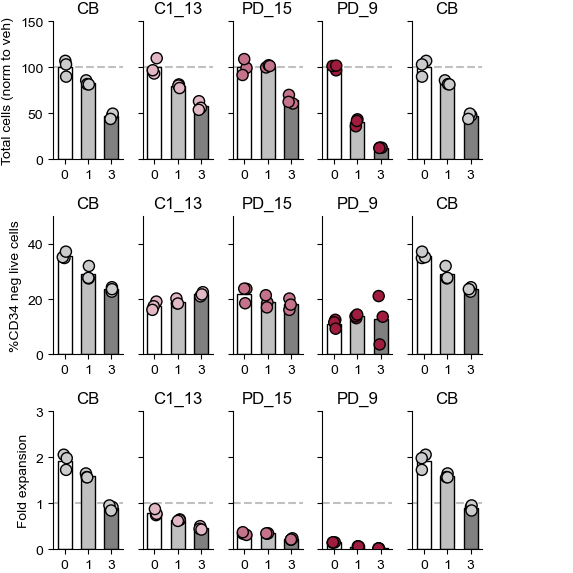

In [7]:
#Now make some plots - sample centric
fig, ax = plt.subplots(3, 6, figsize = (6, 6))
ax = ax.ravel()


for i, c in enumerate(sheets18):
    data = df18.loc[(df18['Source']==c) & (df18['Treatment'].isin(['Vehicle', '1uM_AZA', '3uM_AZA']))]
    x = data['x_coord']
    y1 = data['Total_normalized_to_vehicle']
    y2 = data['CD34neg']
    y3 = data['Total_count']/data['Cells_seeded']
    sn = data['leiden'].drop_duplicates().to_list()[0]

    ax[i].set_title(f'{sn}')
    ax[i+6].set_title(f'{sn}')
    ax[i+12].set_title(f'{sn}')

    #Top row - cell count cf vehicle
    sns.barplot(data=data, x = 'x_coord', y = y1, ax = ax[i], width = width, errorbar=None,  edgecolor = 'k', hue = 'x_coord', palette = treat_col, legend=False)
    sns.stripplot(data=data, x = 'x_coord', y = y1, ax = ax[i], hue='leiden', palette = source_col18, edgecolor = 'k', s=8, linewidth = 1)
    ax[i].set_xlim(-0.5,2.5)
    ax[i].set_ylim(0,150)
    ax[i].set_xticks([0,1,2])
    ax[i].set_xticklabels(['0', '1', '3'])
    ax[i].axhline(y=100, c='silver', ls='--', zorder=-10)
    ax[i].get_legend().remove()
    for d in ['top', 'right']:
        ax[i].spines[d].set_visible(False) 
    

    #Middle row - percent CD34%
    sns.barplot(data=data, x = 'x_coord', y = y2, ax = ax[i+6], width = width, errorbar=None, edgecolor = 'k', hue = 'x_coord', palette = treat_col, legend=False)
    sns.stripplot(data=data, x = 'x_coord', y = y2, ax = ax[i+6], hue='leiden', palette = source_col18,  edgecolor = 'k', s=8, linewidth = 1)
    ax[i+6].set_xlim(-0.5,2.5)
    ax[i+6].set_ylim(0,50)
    ax[i+6].set_xticks([0,1,2])
    ax[i+6].set_xticklabels(['0', '1', '3'])
    ax[i+6].get_legend().remove()
    for d in ['top', 'right']:
        ax[i+6].spines[d].set_visible(False) 

    #Bottom row - raw counts
    sns.barplot(data=data, x = 'x_coord', y = y3, ax = ax[i+12], width = width, errorbar=None, edgecolor = 'k', hue = 'x_coord', palette = treat_col, legend=False)
    sns.stripplot(data=data, x = 'x_coord', y = y3, ax = ax[i+12], hue='leiden', palette = source_col18,  edgecolor = 'k', s=8, linewidth = 1)
    ax[i+12].set_xlim(-0.5,2.5)
    ax[i+12].set_ylim(0,3)
    ax[i+12].set_xticks([0,1,2])
    ax[i+12].set_xticklabels(['0', '1', '3'])
    ax[i+12].axhline(y=1, c='silver', ls='--', zorder=-10)
    ax[i+12].get_legend().remove()
    for d in ['top', 'right']:
        ax[i+12].spines[d].set_visible(False) 

for i in range(17):
    if i == 0:
        ax[i].set_ylabel('Total cells (norm to veh)')
        ax[i].set_xlabel('')
    elif i == 6:
        ax[i].set_ylabel('%CD34 neg live cells')
        ax[i].set_xlabel('')
    elif i == 12:
        ax[i].set_ylabel('Fold expansion')
        ax[i].set_xlabel('')
    else:
        ax[i].set_ylabel('')
        ax[i].set_xlabel('')
        ax[i].set_yticklabels([])

ax[5].set_axis_off()
ax[11].set_axis_off()
ax[17].set_axis_off()


fig.tight_layout()
fig.savefig('../Figures/6_P18_in_vitro_graphs_per_cluster_v2.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)

C:\Users\z3283497\AppData\Local\Temp\ipykernel_5316\475944885.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['x_coord_2'] = data['leiden'].replace(po18)
C:\Users\z3283497\AppData\Local\Temp\ipykernel_5316\475944885.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['x_coord_2'] = data['leiden'].replace(po18)
C:\Users\z3283497\AppData\Local\Temp\ipykernel_5316\475944885.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behav

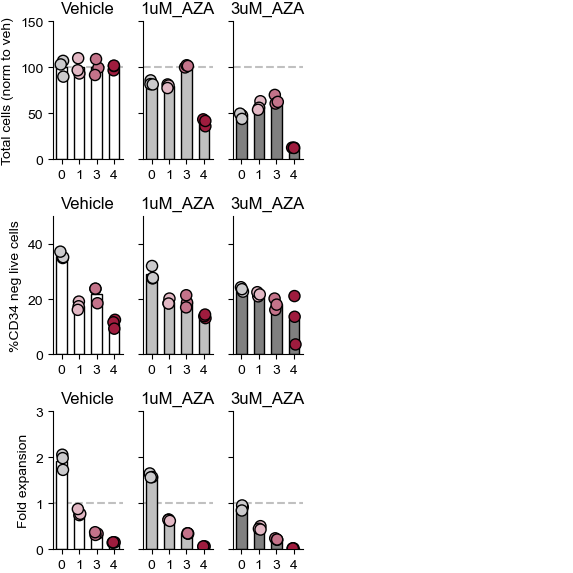

In [8]:
#Now make some plots - AZA concentration centric
fig, ax = plt.subplots(3, 6, figsize = (6, 6))
ax = ax.ravel()


for i, c in enumerate(['Vehicle', '1uM_AZA', '3uM_AZA', 'Vehicle','Vehicle','Vehicle']): #extra vehicle graphs for spacing
    if i > 2:
        continue
    else:
        data = df18.loc[(df18['Treatment']==c)]
        data['x_coord_2'] = data['leiden'].replace(po18)
        x = data['x_coord_2']    
        y1 = data['Total_normalized_to_vehicle']
        y2 = data['CD34neg']
        y3 = data['Total_count']/data['Cells_seeded']
        sn = data['Treatment'].drop_duplicates().to_list()[0]
        cc = treat_col2[c]
    
        ax[i].set_title(f'{sn}')
        ax[i+6].set_title(f'{sn}')
        ax[i+12].set_title(f'{sn}')
    
        #Top row - cell count cf vehicle
        sns.barplot(data=data, x = 'x_coord_2', y = y1, ax = ax[i], width = width, errorbar=None,  edgecolor = 'k',  color = cc, legend=False)
        sns.stripplot(data=data, x = 'x_coord_2', y = y1, ax = ax[i], hue='leiden', palette = source_col18, edgecolor = 'k', s=8, linewidth = 1)
        ax[i].set_xlim(-0.5,3.5)
        ax[i].set_ylim(0,150)
        ax[i].set_xticks([0,1,2,3])
        ax[i].set_xticklabels(['0', '1', '3', '4'])
        ax[i].axhline(y=100, c='silver', ls='--', zorder=-10)
        ax[i].get_legend().remove()
        for d in ['top', 'right']:
            ax[i].spines[d].set_visible(False) 
        
    
        #Middle row - percent CD34%
        sns.barplot(data=data, x = 'x_coord_2', y = y2, ax = ax[i+6], width = width, errorbar=None, edgecolor = 'k',  color = cc, legend=False)
        sns.stripplot(data=data, x = 'x_coord_2', y = y2, ax = ax[i+6], hue='leiden', palette = source_col18,  edgecolor = 'k', s=8, linewidth = 1)
        ax[i+6].set_xlim(-0.5,3.5)
        ax[i+6].set_ylim(0,50)
        ax[i+6].set_xticks([0,1,2,3])
        ax[i+6].set_xticklabels(['0', '1', '3', '4'])
        ax[i+6].get_legend().remove()
        for d in ['top', 'right']:
            ax[i+6].spines[d].set_visible(False) 
    
        #Bottom row - raw counts
        sns.barplot(data=data, x = 'x_coord_2', y = y3, ax = ax[i+12], width = width, errorbar=None, edgecolor = 'k',  color = cc, legend=False)
        sns.stripplot(data=data, x = 'x_coord_2', y = y3, ax = ax[i+12], hue='leiden', palette = source_col18,  edgecolor = 'k', s=8, linewidth = 1)
        ax[i+12].set_xlim(-0.5,3.5)
        ax[i+12].set_ylim(0,3)
        ax[i+12].set_xticks([0,1,2, 3])
        ax[i+12].set_xticklabels(['0', '1', '3', '4'])
        ax[i+12].axhline(y=1, c='silver', ls='--', zorder=-10)
        ax[i+12].get_legend().remove()
        for d in ['top', 'right']:
            ax[i+12].spines[d].set_visible(False) 

for i in range(17):
    if i == 0:
        ax[i].set_ylabel('Total cells (norm to veh)')
        ax[i].set_xlabel('')
    elif i == 6:
        ax[i].set_ylabel('%CD34 neg live cells')
        ax[i].set_xlabel('')
    elif i == 12:
        ax[i].set_ylabel('Fold expansion')
        ax[i].set_xlabel('')
    else:
        ax[i].set_ylabel('')
        ax[i].set_xlabel('')
        ax[i].set_yticklabels([])

ax[3].set_axis_off()
ax[9].set_axis_off()
ax[15].set_axis_off()
ax[4].set_axis_off()
ax[10].set_axis_off()
ax[16].set_axis_off()
ax[5].set_axis_off()
ax[11].set_axis_off()
ax[17].set_axis_off()

fig.tight_layout()
fig.savefig('../Figures/6_P18_in_vitro_graphs_per_concentration_v2.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)

C:\Users\z3283497\AppData\Local\Temp\ipykernel_5316\2935279233.py:58: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['x_coord_2'] = data['leiden'].replace(po18)
C:\Users\z3283497\AppData\Local\Temp\ipykernel_5316\2935279233.py:58: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['x_coord_2'] = data['leiden'].replace(po18)
C:\Users\z3283497\AppData\Local\Temp\ipykernel_5316\2935279233.py:58: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old be

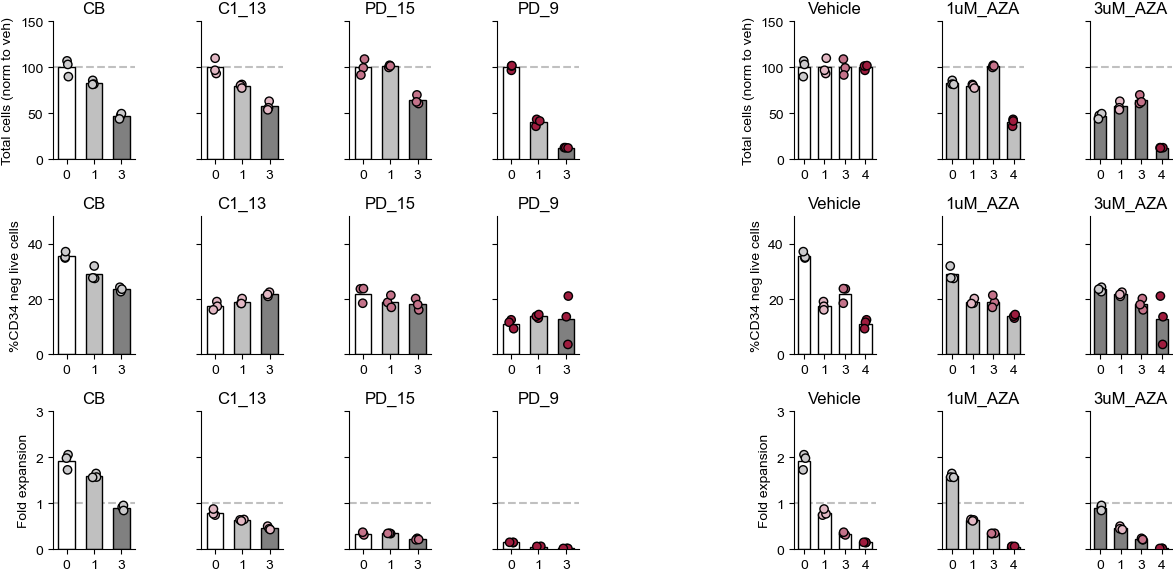

In [9]:
#Super composite graph
fig, ax = plt.subplots(3, 8, figsize = (12,6))
ax = ax.ravel()

for i, c in enumerate(sheets18):
    if i ==4:
        continue
    else:
        data = df18.loc[(df18['Source']==c) & (df18['Treatment'].isin(['Vehicle', '1uM_AZA', '3uM_AZA']))]
        x = data['x_coord']
        y1 = data['Total_normalized_to_vehicle']
        y2 = data['CD34neg']
        y3 = data['Total_count']/data['Cells_seeded']
        sn = data['leiden'].drop_duplicates().to_list()[0]
    
        ax[i].set_title(f'{sn}')
        ax[i+8].set_title(f'{sn}')
        ax[i+16].set_title(f'{sn}')
    
        #Top row - cell count cf vehicle
        sns.barplot(data=data, x = 'x_coord', y = y1, ax = ax[i], width = width, errorbar=None,  edgecolor = 'k', hue = 'x_coord', palette = treat_col, legend=False)
        sns.stripplot(data=data, x = 'x_coord', y = y1, ax = ax[i], hue='leiden', palette = source_col18, edgecolor = 'k', s=sz, linewidth = 1)
        ax[i].set_xlim(-0.5,2.5)
        ax[i].set_ylim(0,150)
        ax[i].set_xticks([0,1,2])
        ax[i].set_xticklabels(['0', '1', '3'])
        ax[i].axhline(y=100, c='silver', ls='--', zorder=-10)
        ax[i].get_legend().remove()
        for d in ['top', 'right']:
            ax[i].spines[d].set_visible(False) 
        
    
        #Middle row - percent CD34%
        sns.barplot(data=data, x = 'x_coord', y = y2, ax = ax[i+8], width = width, errorbar=None, edgecolor = 'k', hue = 'x_coord', palette = treat_col, legend=False)
        sns.stripplot(data=data, x = 'x_coord', y = y2, ax = ax[i+8], hue='leiden', palette = source_col18,  edgecolor = 'k', s=sz, linewidth = 1)
        ax[i+8].set_xlim(-0.5,2.5)
        ax[i+8].set_ylim(0,50)
        ax[i+8].set_xticks([0,1,2])
        ax[i+8].set_xticklabels(['0', '1', '3'])
        ax[i+8].get_legend().remove()
        for d in ['top', 'right']:
            ax[i+8].spines[d].set_visible(False) 
    
        #Bottom row - raw counts
        sns.barplot(data=data, x = 'x_coord', y = y3, ax = ax[i+16], width = width, errorbar=None, edgecolor = 'k', hue = 'x_coord', palette = treat_col, legend=False)
        sns.stripplot(data=data, x = 'x_coord', y = y3, ax = ax[i+16], hue='leiden', palette = source_col18,  edgecolor = 'k', s=sz, linewidth = 1)
        ax[i+16].set_xlim(-0.5,2.5)
        ax[i+16].set_ylim(0,3)
        ax[i+16].set_xticks([0,1,2])
        ax[i+16].set_xticklabels(['0', '1', '3'])
        ax[i+16].axhline(y=1, c='silver', ls='--', zorder=-10)
        ax[i+16].get_legend().remove()
        for d in ['top', 'right']:
            ax[i+16].spines[d].set_visible(False) 

for i, c in enumerate(['Vehicle', '1uM_AZA', '3uM_AZA']): 
    data = df18.loc[(df18['Treatment']==c)]
    data['x_coord_2'] = data['leiden'].replace(po18)
    x = data['x_coord_2']    
    y1 = data['Total_normalized_to_vehicle']
    y2 = data['CD34neg']
    y3 = data['Total_count']/data['Cells_seeded']
    sn = data['Treatment'].drop_duplicates().to_list()[0]
    cc = treat_col2[c]

    ax[i+5].set_title(f'{sn}')
    ax[i+13].set_title(f'{sn}')
    ax[i+21].set_title(f'{sn}')

    #Top row - cell count cf vehicle
    sns.barplot(data=data, x = 'x_coord_2', y = y1, ax = ax[i+5], width = width, errorbar=None,  edgecolor = 'k',  color = cc, legend=False)
    sns.stripplot(data=data, x = 'x_coord_2', y = y1, ax = ax[i+5], hue='leiden', palette = source_col18, edgecolor = 'k', s=sz, linewidth = 1)
    ax[i+5].set_xlim(-0.5,3.5)
    ax[i+5].set_ylim(0,150)
    ax[i+5].set_xticks([0,1,2,3])
    ax[i+5].set_xticklabels(['0', '1', '3', '4'])
    ax[i+5].axhline(y=100, c='silver', ls='--', zorder=-10)
    ax[i+5].get_legend().remove()
    for d in ['top', 'right']:
        ax[i+5].spines[d].set_visible(False) 
    

    #Middle row - percent CD34%
    sns.barplot(data=data, x = 'x_coord_2', y = y2, ax = ax[i+13], width = width, errorbar=None, edgecolor = 'k',  color = cc, legend=False)
    sns.stripplot(data=data, x = 'x_coord_2', y = y2, ax = ax[i+13], hue='leiden', palette = source_col18,  edgecolor = 'k', s=sz, linewidth = 1)
    ax[i+13].set_xlim(-0.5,3.5)
    ax[i+13].set_ylim(0,50)
    ax[i+13].set_xticks([0,1,2,3])
    ax[i+13].set_xticklabels(['0', '1', '3', '4'])
    ax[i+13].get_legend().remove()
    for d in ['top', 'right']:
        ax[i+13].spines[d].set_visible(False) 

    #Bottom row - raw counts
    sns.barplot(data=data, x = 'x_coord_2', y = y3, ax = ax[i+21], width = width, errorbar=None, edgecolor = 'k',  color = cc, legend=False)
    sns.stripplot(data=data, x = 'x_coord_2', y = y3, ax = ax[i+21], hue='leiden', palette = source_col18,  edgecolor = 'k', s=sz, linewidth = 1)
    ax[i+21].set_xlim(-0.5,3.5)
    ax[i+21].set_ylim(0,3)
    ax[i+21].set_xticks([0,1,2, 3])
    ax[i+21].set_xticklabels(['0', '1', '3', '4'])
    ax[i+21].axhline(y=1, c='silver', ls='--', zorder=-10)
    ax[i+21].get_legend().remove()
    for d in ['top', 'right']:
        ax[i+21].spines[d].set_visible(False) 

for i in range(24):
    if i in [0, 5]:
        ax[i].set_ylabel('Total cells (norm to veh)')
        ax[i].set_xlabel('')
    elif i in [8, 13]:
        ax[i].set_ylabel('%CD34 neg live cells')
        ax[i].set_xlabel('')
    elif i in [16,21]:
        ax[i].set_ylabel('Fold expansion')
        ax[i].set_xlabel('')
    else:
        ax[i].set_ylabel('')
        ax[i].set_xlabel('')
        ax[i].set_yticklabels([])

ax[4].set_axis_off()
ax[12].set_axis_off()
ax[20].set_axis_off()


fig.tight_layout()
fig.savefig('../Figures/6_P18_in_vitro_graphs_all_v2.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)

In [10]:
#----P17 plots----
#----Import data from Xioaheng
#Get sheet names
xls = pd.ExcelFile('../Data/P17_count_table_analysis.xls')
sheets17 = xls.sheet_names

In [11]:
#----Manually add initial cell seeding number from original excel formulas
seed_no17 = {'CB':14612,
           'C1D8_l':2825,
           'C1D8_m':4554,
           'C1D8_n':3840 ,
           'PD_n':10000}

#----Manually add colours for dots
source_col17 = {'CB':'#cbcacc',
           'C1_19':'#bbd2c6',
           'C1_4':'#77a48c',
           'C1_0':'#1c6840',
           'PD_0':'#1c6840'}

#Manually add treatment dictionary (extract treatment codes from full df)
treat17 = {'Veh':'Vehicle', 
         '1AZA':'1uM_AZA', 
         '3AZA':'3uM_AZA'}

treat_co17 = {'R':3, 
         'Veh':0, 
         '1AZA':1, 
         '3AZA':2}

#convert cluster names for human readability
source_CL17 = {'CB':'CB',
           'C1D8_l':'C1_19',
           'C1D8_m':'C1_4',
           'C1D8_n':'C1_0',
           'PD_n':'PD_0'}

po17 = {'CB':0,
       'C1_19':1,
       'C1_4':2,
       'C1_0':3,
       'PD_0':4}

In [12]:
#Read in the data and perform calculations as neccesary

df17 = None
for s in sheets17:
    sd = pd.read_excel('../Data/P17_count_table_analysis.xls', sheet_name = s,  engine='xlrd', usecols = 'A:F')
    sd['Source'] = s
    sd['leiden'] = sd['Source'].replace(source_CL17)
    sd['Cells_seeded'] = seed_no17[s]
    sd['Total_count'] = sd['mCD105-hCD45+/Live | Count']/sd['Beads-2 | Count']*10000
    sd['Total_normalized_to_seeding'] = sd['Total_count']/sd['Cells_seeded']
    if s == 'CB':
        sd['Treatment'] = sd['Unnamed: 0'].str.split('_').str[-3].replace(treat17)
        sd['x_coord'] = sd['Unnamed: 0'].str.split('_').str[-3].replace(treat_co17)
    else:
        sd['Treatment'] = sd['Unnamed: 0'].str.split('_').str[-4].replace(treat17)
        sd['x_coord'] = sd['Unnamed: 0'].str.split('_').str[-4].replace(treat_co17)

    #Find vehicle average
    veh_mean = sd.loc[sd['Unnamed: 0'].str.contains('_Veh_')]['Total_count'].mean()
    sd['Total_normalized_to_vehicle'] = sd['Total_count']/veh_mean*100

    sd = sd.loc[sd['Unnamed: 0'].str.contains('Specimen')]

    #Convert percentages
    sd['CD34pos'] = sd['CD34pos | Freq. of Parent'].str.split(' ').str[0].astype('float')
    sd['CD34neg'] = sd['CD34neg | Freq. of Parent'].str.split(' ').str[0].astype('float')
    
    if df17 is None:
        df17 = sd.copy()
    else:
        df17 = pd.concat([sd, df17], ignore_index = True)

df17

C:\Users\z3283497\AppData\Local\Temp\ipykernel_5316\1920297857.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sd['x_coord'] = sd['Unnamed: 0'].str.split('_').str[-3].replace(treat_co17)
C:\Users\z3283497\AppData\Local\Temp\ipykernel_5316\1920297857.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sd['x_coord'] = sd['Unnamed: 0'].str.split('_').str[-4].replace(treat_co17)
C:\Users\z3283497\AppData\Local\Temp\ipykernel_5316\1920297857.py:16: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed

,Unnamed: 0,Beads-2 | Count,mCD105-hCD45+/Live | Count,CD34pos | Count,CD34neg | Freq. of Parent,CD34pos | Freq. of Parent,Source,leiden,Cells_seeded,Total_count,Total_normalized_to_seeding,Treatment,x_coord,Total_normalized_to_vehicle,CD34pos,CD34neg
0,Specimen_001_PD_Veh_n0_1_030.fcs,3666.0,2460,2276,6.75 %,92.5 %,PD_n,PD_0,10000,6710.310966,0.671031,Vehicle,0.0,98.352298,92.5,6.75
1,Specimen_001_PD_Veh_n0_2_031.fcs,3678.0,2518,2325,7.03 %,92.3 %,PD_n,PD_0,10000,6846.112017,0.684611,Vehicle,0.0,100.342719,92.3,7.03
2,Specimen_001_PD_Veh_n0_3_032.fcs,3740.0,2585,2433,5.26 %,94.1 %,PD_n,PD_0,10000,6911.764706,0.691176,Vehicle,0.0,101.304983,94.1,5.26
3,Specimen_001_PD_1AZA_n0_4_033.fcs,3632.0,2484,2247,8.66 %,90.5 %,PD_n,PD_0,10000,6839.207048,0.683921,1uM_AZA,1.0,100.241514,90.5,8.66
4,Specimen_001_PD_1AZA_n0_5_034.fcs,3648.0,2383,2213,6.17 %,92.9 %,PD_n,PD_0,10000,6532.346491,0.653235,1uM_AZA,1.0,95.743892,92.9,6.17
5,Specimen_001_PD_1AZA_n0_6_035.fcs,3632.0,2324,2190,5.03 %,94.2 %,PD_n,PD_0,10000,6398.678414,0.639868,1uM_AZA,1.0,93.784733,94.2,5.03
6,Specimen_001_PD_3AZA_n0_7_036.fcs,4834.0,956,860,9.21 %,90.0 %,PD_n,PD_0,10000,1977.658254,0.197766,3uM_AZA,2.0,28.986322,90.0,9.21
7,Specimen_001_PD_3AZA_n0_8_037.fcs,5008.0,1031,939,8.15 %,91.1 %,PD_n,PD_0,10000,2058.706070,0.205871,3uM_AZA,2.0,30.174231,91.1,8.15
8,Specimen_001_PD_3AZA_n0_9_038.fcs,4995.0,1125,987,11.6 %,87.7 %,PD_n,PD_0,10000,2252.252252,0.225225,3uM_AZA,2.0,33.011016,87.7,11.60
9,Specimen_001_C1D8_Veh_n0_1_021.fcs,5370.0,1159,1097,4.83 %,94.7 %,C1D8_n,C1_0,3840,2158.286778,0.562054,Vehicle,0.0,101.060924,94.7,4.83


In [13]:
#Rename one column to match p18
df17['mCD105- | Count'] = df17['mCD105-hCD45+/Live | Count']
df17.drop(columns = 'mCD105-hCD45+/Live | Count', inplace=True)

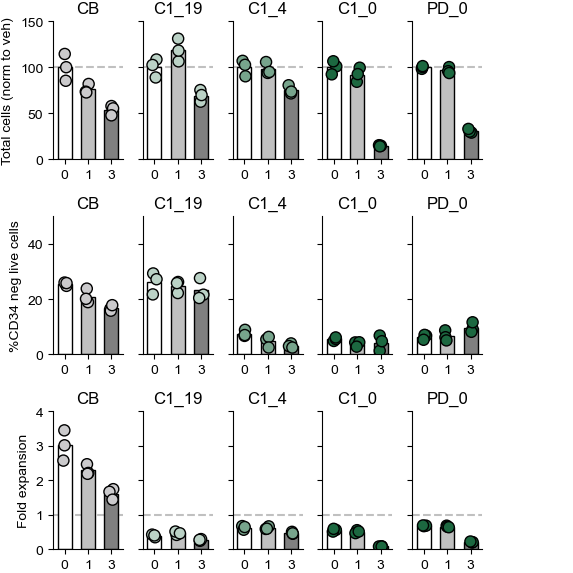

In [14]:
#Now make some plots
fig, ax = plt.subplots(3, 6, figsize = (6, 6))
ax = ax.ravel()

for i, c in enumerate(sheets17):
    data = df17.loc[(df17['Source']==c) & (df17['Treatment'].isin(['Vehicle', '1uM_AZA', '3uM_AZA']))]
    x = data['x_coord']
    y1 = data['Total_normalized_to_vehicle']
    y2 = data['CD34neg']
    y3 = data['Total_count']/data['Cells_seeded']
    sn = data['leiden'].drop_duplicates().to_list()[0]

    ax[i].set_title(f'{sn}')
    ax[i+6].set_title(f'{sn}')
    ax[i+12].set_title(f'{sn}')


    #Top row - cell count cf vehicle
    sns.barplot(data=data, x = 'x_coord', y = y1, ax = ax[i], width = width, errorbar=None,  edgecolor = 'k', hue = 'x_coord', palette = treat_col, legend=False)
    sns.stripplot(data=data, x = 'x_coord', y = y1, ax = ax[i], hue='leiden', palette = source_col17, edgecolor = 'k', s=8, linewidth = 1)
    ax[i].set_xlim(-0.5,2.5)
    ax[i].set_ylim(0,150)
    ax[i].set_xticks([0,1,2])
    ax[i].set_xticklabels(['0', '1', '3'])
    ax[i].axhline(y=100, c='silver', ls='--', zorder=-10)
    ax[i].get_legend().remove()
    for d in ['top', 'right']:
        ax[i].spines[d].set_visible(False) 
    

    #Middle row - percent CD34%
    sns.barplot(data=data, x = 'x_coord', y = y2, ax = ax[i+6], width = width, errorbar=None, edgecolor = 'k', hue = 'x_coord', palette = treat_col, legend=False)
    sns.stripplot(data=data, x = 'x_coord', y = y2, ax = ax[i+6], hue='leiden', palette = source_col17,  edgecolor = 'k', s=8, linewidth = 1)
    ax[i+6].set_xlim(-0.5,2.5)
    ax[i+6].set_ylim(0,50)
    ax[i+6].set_xticks([0,1,2])
    ax[i+6].set_xticklabels(['0', '1', '3'])
    ax[i+6].get_legend().remove()
    for d in ['top', 'right']:
        ax[i+6].spines[d].set_visible(False) 

    #Bottom row - raw counts
    sns.barplot(data=data, x = 'x_coord', y = y3, ax = ax[i+12], width = width, errorbar=None, edgecolor = 'k', hue = 'x_coord', palette = treat_col, legend=False)
    sns.stripplot(data=data, x = 'x_coord', y = y3, ax = ax[i+12], hue='leiden', palette = source_col17,  edgecolor = 'k', s=8, linewidth = 1)
    ax[i+12].set_xlim(-0.5,2.5)
    ax[i+12].set_ylim(0,4)
    ax[i+12].set_xticks([0,1,2])
    ax[i+12].set_xticklabels(['0', '1', '3'])
    ax[i+12].axhline(y=1, c='silver', ls='--', zorder=-10)
    ax[i+12].get_legend().remove()
    for d in ['top', 'right']:
        ax[i+12].spines[d].set_visible(False) 

for i in range(17):
    if i == 0:
        ax[i].set_ylabel('Total cells (norm to veh)')
        ax[i].set_xlabel('')
    elif i == 6:
        ax[i].set_ylabel('%CD34 neg live cells')
        ax[i].set_xlabel('')
    elif i == 12:
        ax[i].set_ylabel('Fold expansion')
        ax[i].set_xlabel('')
    else:
        ax[i].set_ylabel('')
        ax[i].set_xlabel('')
        ax[i].set_yticklabels([])

ax[5].set_axis_off()
ax[11].set_axis_off()
ax[17].set_axis_off()

fig.tight_layout()
fig.savefig('../Figures/6_P17_in_vitro_graphs_per_cluster_v2.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)

C:\Users\z3283497\AppData\Local\Temp\ipykernel_5316\317509676.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['x_coord_2'] = data['leiden'].replace(po17)
C:\Users\z3283497\AppData\Local\Temp\ipykernel_5316\317509676.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['x_coord_2'] = data['leiden'].replace(po17)
C:\Users\z3283497\AppData\Local\Temp\ipykernel_5316\317509676.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behav

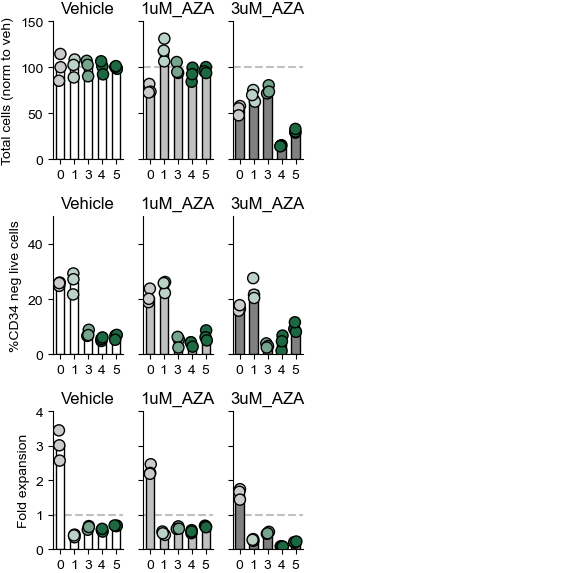

In [15]:
#Now make some plots - AZA concentration centric
fig, ax = plt.subplots(3, 6, figsize = (6, 6))
ax = ax.ravel()

for i, c in enumerate(['Vehicle', '1uM_AZA', '3uM_AZA', 'Vehicle','Vehicle','Vehicle']): #extra vehicle graphs for spacing
    if i > 2:
        continue
    else:
        data = df17.loc[(df17['Treatment']==c)]
        data['x_coord_2'] = data['leiden'].replace(po17)
        x = data['x_coord_2']    
        y1 = data['Total_normalized_to_vehicle']
        y2 = data['CD34neg']
        y3 = data['Total_count']/data['Cells_seeded']
        sn = data['Treatment'].drop_duplicates().to_list()[0]
        cc = treat_col2[c]
    
        ax[i].set_title(f'{sn}')
        ax[i+6].set_title(f'{sn}')
        ax[i+12].set_title(f'{sn}')
    
        #Top row - cell count cf vehicle
        sns.barplot(data=data, x = 'x_coord_2', y = y1, ax = ax[i], width = width, errorbar=None,  edgecolor = 'k',  color = cc, legend=False)
        sns.stripplot(data=data, x = 'x_coord_2', y = y1, ax = ax[i], hue='leiden', palette = source_col17, edgecolor = 'k', s=8, linewidth = 1)
        ax[i].set_xlim(-0.5,4.5)
        ax[i].set_ylim(0,150)
        ax[i].set_xticks([0,1,2,3, 4])
        ax[i].set_xticklabels(['0', '1', '3', '4', '5'])
        ax[i].axhline(y=100, c='silver', ls='--', zorder=-10)
        ax[i].get_legend().remove()
        for d in ['top', 'right']:
            ax[i].spines[d].set_visible(False) 
        
    
        #Middle row - percent CD34%
        sns.barplot(data=data, x = 'x_coord_2', y = y2, ax = ax[i+6], width = width, errorbar=None, edgecolor = 'k',  color = cc, legend=False)
        sns.stripplot(data=data, x = 'x_coord_2', y = y2, ax = ax[i+6], hue='leiden', palette = source_col17,  edgecolor = 'k', s=8, linewidth = 1)
        ax[i+6].set_xlim(-0.5,4.5)
        ax[i+6].set_ylim(0,50)
        ax[i+6].set_xticks([0,1,2,3, 4])
        ax[i+6].set_xticklabels(['0', '1', '3', '4', '5'])
        ax[i+6].get_legend().remove()
        for d in ['top', 'right']:
            ax[i+6].spines[d].set_visible(False) 
    
        #Bottom row - raw counts
        sns.barplot(data=data, x = 'x_coord_2', y = y3, ax = ax[i+12], width = width, errorbar=None, edgecolor = 'k',  color = cc, legend=False)
        sns.stripplot(data=data, x = 'x_coord_2', y = y3, ax = ax[i+12], hue='leiden', palette = source_col17,  edgecolor = 'k', s=8, linewidth = 1)
        ax[i+12].set_xlim(-0.5,4.5)
        ax[i+12].set_ylim(0,4)
        ax[i+12].set_xticks([0,1,2, 3, 4])
        ax[i+12].set_xticklabels(['0', '1', '3', '4', '5'])
        ax[i+12].axhline(y=1, c='silver', ls='--', zorder=-10)
        ax[i+12].get_legend().remove()
        for d in ['top', 'right']:
            ax[i+12].spines[d].set_visible(False) 

for i in range(17):
    if i == 0:
        ax[i].set_ylabel('Total cells (norm to veh)')
        ax[i].set_xlabel('')
    elif i == 6:
        ax[i].set_ylabel('%CD34 neg live cells')
        ax[i].set_xlabel('')
    elif i == 12:
        ax[i].set_ylabel('Fold expansion')
        ax[i].set_xlabel('')
    else:
        ax[i].set_ylabel('')
        ax[i].set_xlabel('')
        ax[i].set_yticklabels([])

ax[3].set_axis_off()
ax[9].set_axis_off()
ax[15].set_axis_off()
ax[4].set_axis_off()
ax[10].set_axis_off()
ax[16].set_axis_off()
ax[5].set_axis_off()
ax[11].set_axis_off()
ax[17].set_axis_off()


fig.tight_layout()
fig.savefig('../Figures/6_P17_in_vitro_graphs_per_concentration_v2.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)

C:\Users\z3283497\AppData\Local\Temp\ipykernel_5316\1354727533.py:55: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['x_coord_2'] = data['leiden'].replace(po17)
C:\Users\z3283497\AppData\Local\Temp\ipykernel_5316\1354727533.py:55: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['x_coord_2'] = data['leiden'].replace(po17)
C:\Users\z3283497\AppData\Local\Temp\ipykernel_5316\1354727533.py:55: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old be

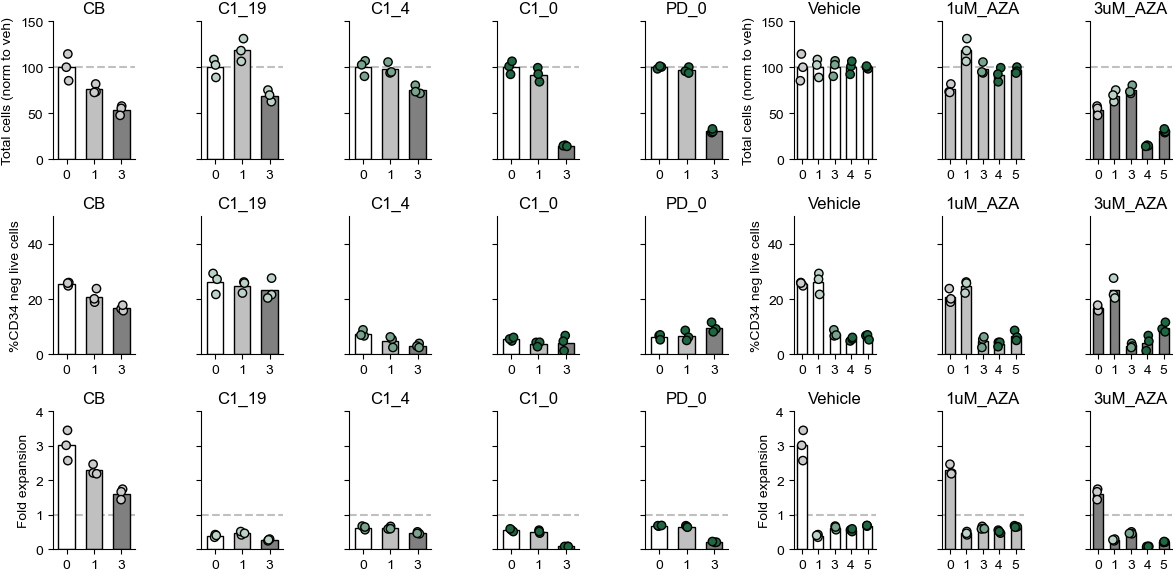

In [16]:
#Super composite graph
fig, ax = plt.subplots(3, 8, figsize = (12,6))
ax = ax.ravel()

for i, c in enumerate(sheets17):
    data = df17.loc[(df17['Source']==c) & (df17['Treatment'].isin(['Vehicle', '1uM_AZA', '3uM_AZA']))]
    x = data['x_coord']
    y1 = data['Total_normalized_to_vehicle']
    y2 = data['CD34neg']
    y3 = data['Total_count']/data['Cells_seeded']
    sn = data['leiden'].drop_duplicates().to_list()[0]

    ax[i].set_title(f'{sn}')
    ax[i+8].set_title(f'{sn}')
    ax[i+16].set_title(f'{sn}')

    #Top row - cell count cf vehicle
    sns.barplot(data=data, x = 'x_coord', y = y1, ax = ax[i], width = width, errorbar=None,  edgecolor = 'k', hue = 'x_coord', palette = treat_col, legend=False)
    sns.stripplot(data=data, x = 'x_coord', y = y1, ax = ax[i], hue='leiden', palette = source_col17, edgecolor = 'k', s=sz, linewidth = 1)
    ax[i].set_xlim(-0.5,2.5)
    ax[i].set_ylim(0,150)
    ax[i].set_xticks([0,1,2])
    ax[i].set_xticklabels(['0', '1', '3'])
    ax[i].axhline(y=100, c='silver', ls='--', zorder=-10)
    ax[i].get_legend().remove()
    for d in ['top', 'right']:
        ax[i].spines[d].set_visible(False) 
    

    #Middle row - percent CD34%
    sns.barplot(data=data, x = 'x_coord', y = y2, ax = ax[i+8], width = width, errorbar=None, edgecolor = 'k', hue = 'x_coord', palette = treat_col, legend=False)
    sns.stripplot(data=data, x = 'x_coord', y = y2, ax = ax[i+8], hue='leiden', palette = source_col17,  edgecolor = 'k', s=sz, linewidth = 1)
    ax[i+8].set_xlim(-0.5,2.5)
    ax[i+8].set_ylim(0,50)
    ax[i+8].set_xticks([0,1,2])
    ax[i+8].set_xticklabels(['0', '1', '3'])
    ax[i+8].get_legend().remove()
    for d in ['top', 'right']:
        ax[i+8].spines[d].set_visible(False) 

    #Bottom row - raw counts
    sns.barplot(data=data, x = 'x_coord', y = y3, ax = ax[i+16], width = width, errorbar=None, edgecolor = 'k', hue = 'x_coord', palette = treat_col, legend=False)
    sns.stripplot(data=data, x = 'x_coord', y = y3, ax = ax[i+16], hue='leiden', palette = source_col17,  edgecolor = 'k', s=sz, linewidth = 1)
    ax[i+16].set_xlim(-0.5,2.5)
    ax[i+16].set_ylim(0,4)
    ax[i+16].set_xticks([0,1,2])
    ax[i+16].set_xticklabels(['0', '1', '3'])
    ax[i+16].axhline(y=1, c='silver', ls='--', zorder=-10)
    ax[i+16].get_legend().remove()
    for d in ['top', 'right']:
        ax[i+16].spines[d].set_visible(False) 

for i, c in enumerate(['Vehicle', '1uM_AZA', '3uM_AZA']): 
    data = df17.loc[(df17['Treatment']==c)]
    data['x_coord_2'] = data['leiden'].replace(po17)
    x = data['x_coord_2']    
    y1 = data['Total_normalized_to_vehicle']
    y2 = data['CD34neg']
    y3 = data['Total_count']/data['Cells_seeded']
    sn = data['Treatment'].drop_duplicates().to_list()[0]
    cc = treat_col2[c]

    ax[i+5].set_title(f'{sn}')
    ax[i+13].set_title(f'{sn}')
    ax[i+21].set_title(f'{sn}')

    #Top row - cell count cf vehicle
    sns.barplot(data=data, x = 'x_coord_2', y = y1, ax = ax[i+5], width = width, errorbar=None,  edgecolor = 'k',  color = cc, legend=False)
    sns.stripplot(data=data, x = 'x_coord_2', y = y1, ax = ax[i+5], hue='leiden', palette = source_col17, edgecolor = 'k', s=sz, linewidth = 1)
    ax[i+5].set_xlim(-0.5,4.5)
    ax[i+5].set_ylim(0,150)
    ax[i+5].set_xticks([0,1,2,3, 4])
    ax[i+5].set_xticklabels(['0', '1', '3', '4', '5'])
    ax[i+5].axhline(y=100, c='silver', ls='--', zorder=-10)
    ax[i+5].get_legend().remove()
    for d in ['top', 'right']:
        ax[i+5].spines[d].set_visible(False) 
    

    #Middle row - percent CD34%
    sns.barplot(data=data, x = 'x_coord_2', y = y2, ax = ax[i+13], width = width, errorbar=None, edgecolor = 'k',  color = cc, legend=False)
    sns.stripplot(data=data, x = 'x_coord_2', y = y2, ax = ax[i+13], hue='leiden', palette = source_col17,  edgecolor = 'k', s=sz, linewidth = 1)
    ax[i+13].set_xlim(-0.5,4.5)
    ax[i+13].set_ylim(0,50)
    ax[i+13].set_xticks([0,1,2,3, 4])
    ax[i+13].set_xticklabels(['0', '1', '3', '4', '5'])
    ax[i+13].get_legend().remove()
    for d in ['top', 'right']:
        ax[i+13].spines[d].set_visible(False) 

    #Bottom row - raw counts
    sns.barplot(data=data, x = 'x_coord_2', y = y3, ax = ax[i+21], width = width, errorbar=None, edgecolor = 'k',  color = cc, legend=False)
    sns.stripplot(data=data, x = 'x_coord_2', y = y3, ax = ax[i+21], hue='leiden', palette = source_col17,  edgecolor = 'k', s=sz, linewidth = 1)
    ax[i+21].set_xlim(-0.5,4.5)
    ax[i+21].set_ylim(0,4)
    ax[i+21].set_xticks([0,1,2, 3, 4])
    ax[i+21].set_xticklabels(['0', '1', '3', '4', '5'])
    ax[i+21].axhline(y=1, c='silver', ls='--', zorder=-10)
    ax[i+21].get_legend().remove()
    for d in ['top', 'right']:
        ax[i+21].spines[d].set_visible(False) 

for i in range(24):
    if i in [0, 5]:
        ax[i].set_ylabel('Total cells (norm to veh)')
        ax[i].set_xlabel('')
    elif i in [8, 13]:
        ax[i].set_ylabel('%CD34 neg live cells')
        ax[i].set_xlabel('')
    elif i in [16,21]:
        ax[i].set_ylabel('Fold expansion')
        ax[i].set_xlabel('')
    else:
        ax[i].set_ylabel('')
        ax[i].set_xlabel('')
        ax[i].set_yticklabels([])


fig.tight_layout()
fig.savefig('../Figures/6_P17_in_vitro_graphs_all_v2.pdf',bbox_inches='tight', format = 'pdf', dpi = 600)

In [17]:
#Now want to get stats - have exported Xiaoheng's ordinary one-way ANOVA data with multiple comparisons - pull in here to combine it all

In [18]:
pop_dict = dict(zip(['l', 'm', 'n', 'control', 'suba', 'subb', 'subc'], ['19', '4', '0', 'control', '13', '15', '9']))

In [19]:
directory = '../Data/Fig6_stats/'

df = None

for f in os.listdir(directory):
    detail = f.split('of')[1]
    pat = detail.split('_')[0]
    tp = detail.split('_')[1]
    if tp == 'mixed CB':
        tp = 'CB'
        pop = 'control'
    else:
       pop =  detail.split('_')[2]

    if 'CD34neg_percentage' in detail:
        comp = 'percent_CD34neg'
    elif 'seeding' in detail:
        comp = 'normalised_to_seeding'
    elif 'Vehicle' in detail:
        comp = 'normalised_to_vehicle'
    
    filename = os.path.join(directory, f)
    df0 = pd.read_csv(filename)
    id = df0.iloc[:,0].to_dict()
    for key, value in id.items():
        if pd.notna(value):
            if 'multiple comparisons' in value:
                col1 = key
            if 'details' in value:
                col2 = key
            if 'Compact' in value:
                col3 = key
    
    df1 = df0.iloc[col1:col2-1]
    df1.columns = df1.iloc[0]
    df1 = df1.iloc[1:].reset_index(drop=True)
    df1 = df1.dropna(axis=1)
     
    df2 = df0.iloc[col2:col3-1]
    df2.columns = df2.iloc[0]
    df2 = df2.iloc[1:].reset_index(drop=True)
    df2 = df2.dropna(axis=1)
    
    df3 = pd.merge(df2, df1)
    df3 = df3.drop(columns = 'Tukey\'s multiple comparisons test')

    df3['Patient'] = pat
    df3['Population'] = pop
    df3['Timepoint'] = tp
    df3['Analysis'] = comp

    df3 = df3.loc[df3['Test details'].isin(['  Vehicle vs. 1uM AZA', '  Vehicle vs. 3uM AZA', '  1uM AZA vs. 3uM AZA'])]

    if df is None:
        df = df3.copy()
    else:
        df = pd.concat([df, df3], ignore_index = True) 

df.columns = [ 'Test details', 
              'Mean 1',             
              'Mean 2',
               'Mean diff.',        
              'SE of diff.',                 
              'n1',
                       'n2',                  
              'q',                 
              'DF',
               '95.00% CI of diff.',   
              'Below threshold?',            
              'Summary',
             'Adjusted P Value',                  
              'Columns_compared',            
              'Patient',
               'Population',          
              'Timepoint',
             'Analysis']  

df['Population2'] = df['Population'].replace(pop_dict)

df = df[['Patient', 'Population', 'Population2', 'Timepoint', 'Analysis','Test details', 'Mean 1', 'Mean 2', 'Mean diff.', 'SE of diff.', 'n1','n2', 'q', 'DF', '95.00% CI of diff.', 'Below threshold?', 'Summary', 'Adjusted P Value', 'Columns_compared']]  
df
df.to_excel('../Figures/Figure6_stats_summary_per_cluster_v2.xlsx', index = None)

In [20]:
#Export a table with all the data
df17['patient_alias'] = 'P17'
df18['patient_alias'] = 'P18'
alldata = pd.concat([df17, df18])

In [21]:
alldata.columns = ['FCS_file', 'Beads-2 | Count', 'CD34pos | Count','CD34neg | Freq. of Parent', 'CD34pos | Freq. of Parent', 'Source','leiden', 'Cells_seeded', 'Total_count', 'Total_normalized_to_seeding','Treatment', 'x_coord', 'Total_normalized_to_vehicle', 'CD34pos', 'CD34neg', 'mCD105- | Count', 'patient_alias']

In [22]:
alldata[['FCS_file',  'patient_alias', 'leiden','Treatment', 'Cells_seeded','Beads-2 | Count', 'mCD105- | Count', 'CD34pos | Count','Total_count', 
         'Total_normalized_to_seeding','Total_normalized_to_vehicle', 'CD34pos','CD34neg']].to_excel('../Figures/Figure6_all_count_data.xlsx', index=None)